# 3 SVD and Clustering

Report of <br>
Jonas Ortner: 2265527 <br>
Marmee Pandya: 1963521

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

%load_ext autoreload
%autoreload 2
from a03_helper import *

In [2]:
# Cluster the normalized climate data into 5 clusters using k-means and store
# the vector giving the cluster labels for each location.
climate = pd.read_csv("data/worldclim.csv")
X = (climate - climate.mean()) / climate.std()
X_clusters = KMeans(5).fit(X).labels_

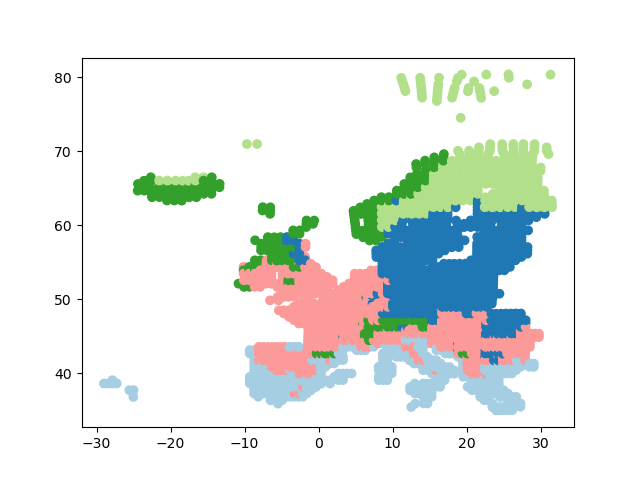

In [17]:
# Plot the results to the map: use the cluster labels to give the color to each
# point.
plot_xy(lon, lat, X_clusters)
plt.savefig('images/a03_3_clusters_by_coordinates.png', dpi=300, bbox_inches='tight')

## 3b

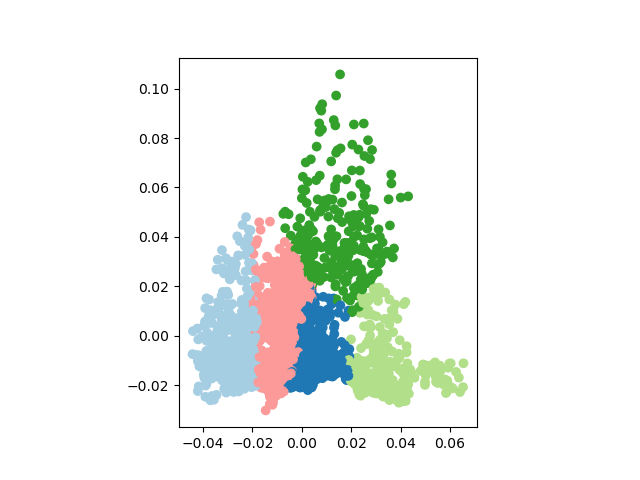

In [18]:
U, s, Vt = np.linalg.svd(X)
plot_xy(U[:, 0], U[:, 1], X_clusters)
plt.savefig('images/a03_3_clusters_first_two_principal_components.png', dpi=300, bbox_inches='tight')


## 3c

In [15]:
# Compute the PCA scores, store in Z (of shape N x k)
Z = 3
U, s, Vt = np.linalg.svd(X)
S = np.diag(s)
# YOUR PART HERE
#computing score matrix
S_PCA = U[:, :Z] * np.diag(S)[:Z]

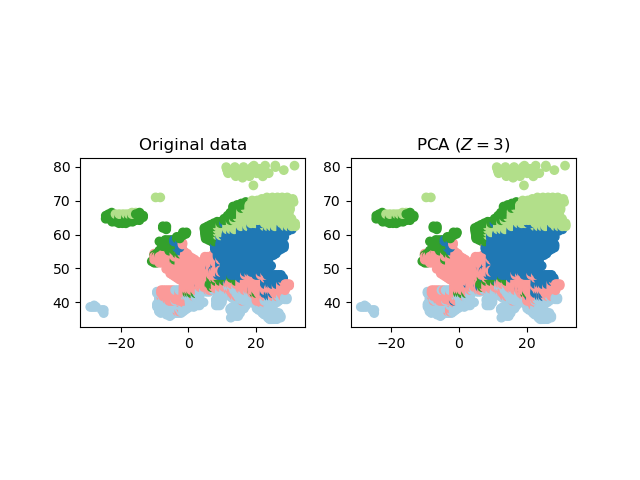

In [16]:
# cluster and visualize
S_PCA_clusters = KMeans(5).fit(S_PCA).labels_
# match clusters as well as possible (try without)
S_PCA_clusters = match_categories(X_clusters, S_PCA_clusters)
nextplot()
axs = plt.gcf().subplots(1, 2)
plot_xy(lon, lat, X_clusters, axis=axs[0])
axs[0].set_title("Original data")
plot_xy(lon, lat, S_PCA_clusters, axis=axs[1])
axs[1].set_title(f"PCA $(Z={Z}$)")

plt.savefig(f'images/a03_3_clusters_pca_comparison_z{Z}.png', dpi=300, bbox_inches='tight')